In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import missingno as ms
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv('../data/credit_card_fraud_dataset.csv', sep=';')
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [5]:
df.shape

(100000, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  str    
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  str    
 5   Location         100000 non-null  str    
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 9.3 MB


In [7]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

In [8]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [9]:
df.describe()

,TransactionID,TransactionDate,Amount,MerchantID,IsFraud
count,100000.000000,100000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2024-04-21 13:06:09.973745,2497.092666,501.676070,0.010000
min,1.000000,2023-10-21 09:28:35.824439,1.050000,1.000000,0.000000
25%,25000.750000,2024-01-20 23:18:20.586056,1247.955000,252.000000,0.000000
50%,50000.500000,2024-04-21 13:39:35.701439,2496.500000,503.000000,0.000000
75%,75000.250000,2024-07-21 22:28:05.702624,3743.592500,753.000000,0.000000
max,100000.000000,2024-10-21 09:20:35.961088,4999.770000,1000.000000,1.000000
std,28867.657797,NaN,1442.415999,288.715868,0.099499


In [10]:
df.describe().columns.difference(['TransactionID', 'TransactionDate', 'MerchantID'])

Index(['Amount', 'IsFraud'], dtype='str')

In [11]:
df[['Amount']].describe()

,Amount
count,100000.000000
mean,2497.092666
std,1442.415999
min,1.050000
25%,1247.955000
50%,2496.500000
75%,3743.592500
max,4999.770000


In [12]:
df['IsFraud'].value_counts()

IsFraud
0    99000
1     1000
Name: count, dtype: int64

In [13]:
proportions = df['IsFraud'].value_counts(normalize=True)*100
proportions

IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64

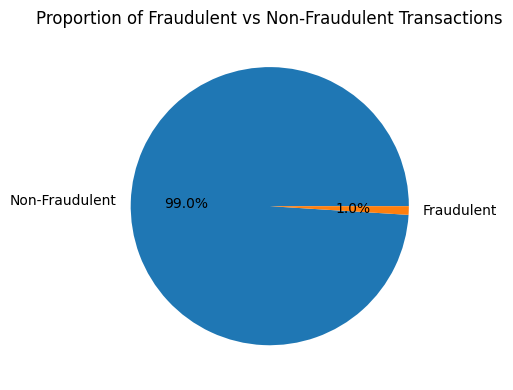

In [14]:
plt.figure(figsize=(15, 4))
plt.pie(proportions, autopct='%1.1f%%', labels=['Non-Fraudulent', 'Fraudulent'])
plt.title('Proportion of Fraudulent vs Non-Fraudulent Transactions')
plt.tight_layout()
plt.show()

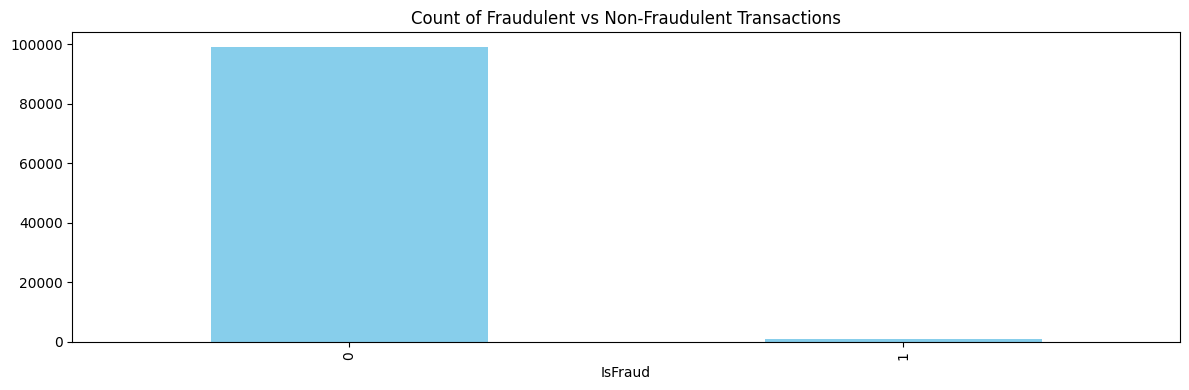

In [15]:
plt.figure(figsize=(12, 4))
df['IsFraud'].value_counts().plot(kind='bar', color=['skyblue'])
plt.title('Count of Fraudulent vs Non-Fraudulent Transactions')
plt.tight_layout()
plt.show()

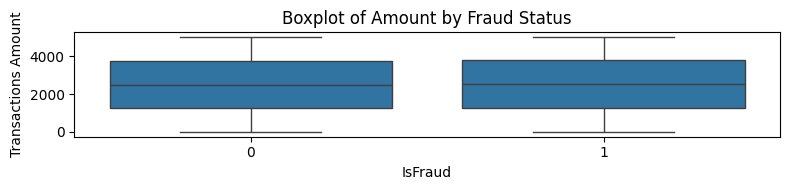

In [16]:
plt.figure(figsize=(8, 2))
sns.boxplot(data=df, x='IsFraud', y='Amount')
plt.title("Boxplot of Amount by Fraud Status")
plt.ylabel("Transactions Amount")
plt.tight_layout()
plt.show()

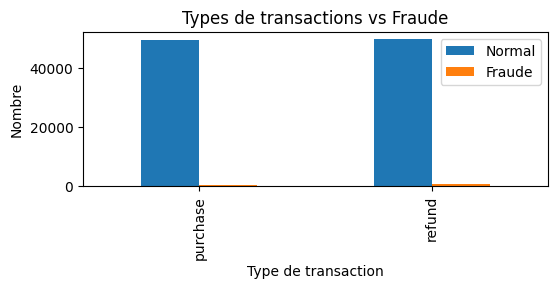

In [17]:
df.groupby(['TransactionType', 'IsFraud'])['IsFraud'].count().unstack().plot(kind='bar', figsize=(6,2))
plt.title("Types de transactions vs Fraude")
plt.xlabel("Type de transaction")
plt.ylabel("Nombre")
plt.legend(['Normal', 'Fraude'])
plt.show()

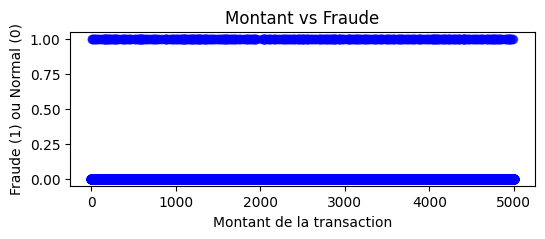

In [18]:
plt.figure(figsize=(6, 2))
plt.scatter(df['Amount'], df['IsFraud'], alpha=0.3, color='blue')
plt.xlabel("Montant de la transaction")
plt.ylabel("Fraude (1) ou Normal (0)")
plt.title("Montant vs Fraude")
plt.show()

In [19]:
df['Hours'] = df['TransactionDate'].dt.hour

In [20]:
df['Hours']

0        14
1        13
2        10
3        23
4        18
         ..
99995     0
99996    23
99997    19
99998     9
99999    19
Name: Hours, Length: 100000, dtype: int32

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionID    100000 non-null  int64         
 1   TransactionDate  100000 non-null  datetime64[us]
 2   Amount           100000 non-null  float64       
 3   MerchantID       100000 non-null  int64         
 4   TransactionType  100000 non-null  str           
 5   Location         100000 non-null  str           
 6   IsFraud          100000 non-null  int64         
 7   Hours            100000 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(1), int64(3), str(2)
memory usage: 7.2 MB


In [22]:
df['DayOfWeek'] = df['TransactionDate'].dt.day
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,Hours,DayOfWeek
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,14,3
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,13,19
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,10,8
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,23,13
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,18,12


In [23]:
df['DayOfWeek'].rename('Days')

0         3
1        19
2         8
3        13
4        12
         ..
99995     7
99996    22
99997    31
99998    18
99999     5
Name: Days, Length: 100000, dtype: int32

In [24]:
df[['TransactionDate', 'Hours', 'DayOfWeek']].head()

,TransactionDate,Hours,DayOfWeek
0,2024-04-03 14:15:35.462794,14,3
1,2024-03-19 13:20:35.462824,13,19
2,2024-01-08 10:08:35.462834,10,8
3,2024-04-13 23:50:35.462850,23,13
4,2024-07-12 18:51:35.462858,18,12


In [25]:
fraudes = df[df['IsFraud'] == 1]

In [26]:
fraudes_par_heure = fraudes.groupby('Hours')['IsFraud'].count()

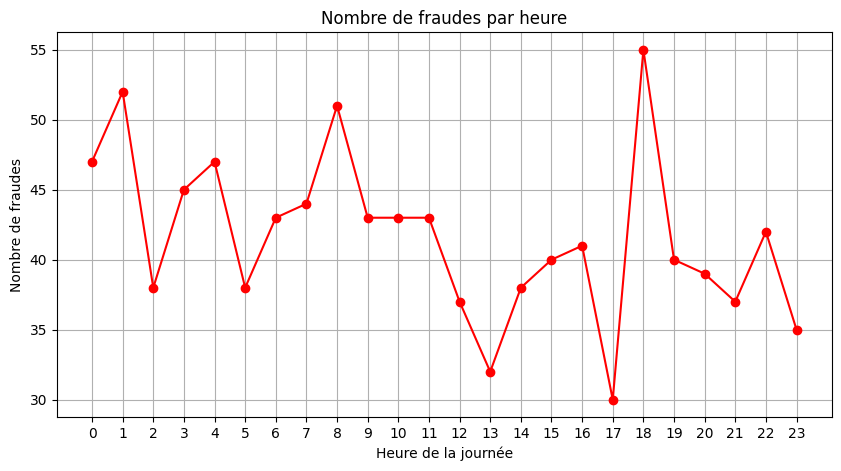

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(fraudes_par_heure.index, fraudes_par_heure.values, marker='o', color='red')
plt.title("Nombre de fraudes par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre de fraudes")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   TransactionID    100000 non-null  int64         
 1   TransactionDate  100000 non-null  datetime64[us]
 2   Amount           100000 non-null  float64       
 3   MerchantID       100000 non-null  int64         
 4   TransactionType  100000 non-null  str           
 5   Location         100000 non-null  str           
 6   IsFraud          100000 non-null  int64         
 7   Hours            100000 non-null  int32         
 8   DayOfWeek        100000 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(2), int64(3), str(2)
memory usage: 7.6 MB


In [29]:
fraudes_par_mois = fraudes.groupby('DayOfWeek')['IsFraud'].count()

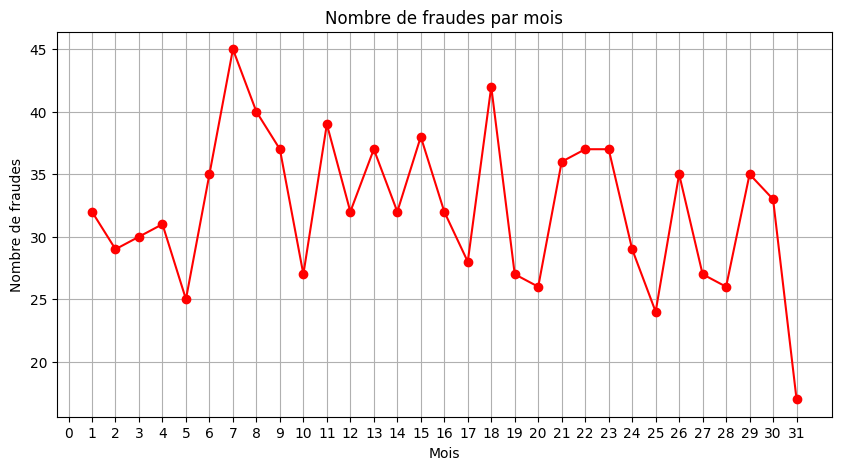

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(fraudes_par_mois.index, fraudes_par_mois.values, marker='o', color='red')
plt.title("Nombre de fraudes par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de fraudes")
plt.xticks(range(0, 32))
plt.grid(True)
plt.show()

In [31]:
fraudes_par_endroit = fraudes.groupby('Location')['IsFraud'].count()

In [32]:
fraudes_par_endroit

Location
Chicago          95
Dallas           99
Houston         105
Los Angeles      95
New York        116
Philadelphia     90
Phoenix          99
San Antonio      99
San Diego       115
San Jose         87
Name: IsFraud, dtype: int64

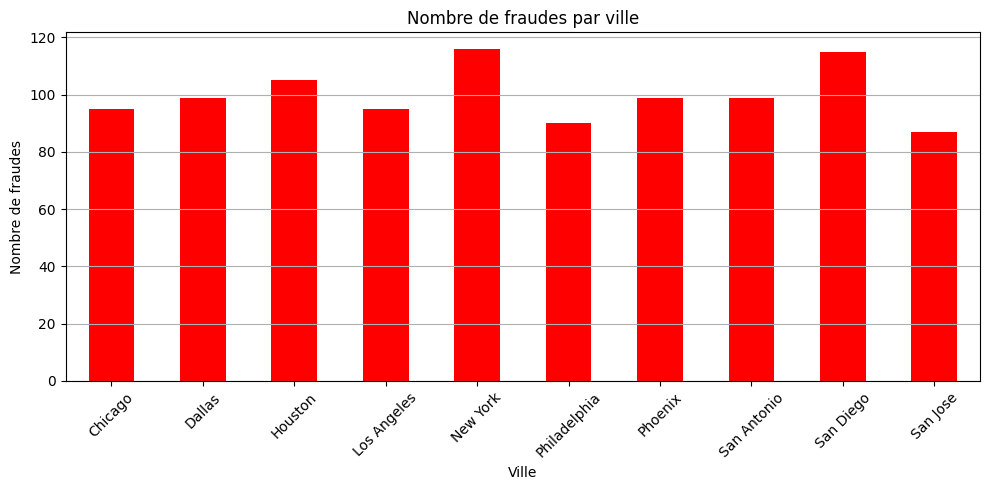

In [33]:
plt.figure(figsize=(10, 5))
fraudes_par_endroit.plot(kind='bar', color='red')
plt.title("Nombre de fraudes par ville")
plt.xlabel("Ville")
plt.ylabel("Nombre de fraudes")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [34]:
df_encoded = pd.get_dummies(df, columns=['TransactionType', 'Location'])

In [35]:
X = df_encoded[['Amount', 'Hours', 'DayOfWeek',
                 'TransactionType_purchase', 'TransactionType_refund']]
X = pd.concat([X, df_encoded[[col for col in df_encoded.columns 
                               if col.startswith('Location_')]]], axis=1)
y = df_encoded['IsFraud']

In [36]:
X.head()

,Amount,Hours,DayOfWeek,TransactionType_purchase,TransactionType_refund,Location_Chicago,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,4189.27,14,3,False,True,False,False,False,False,False,False,False,True,False,False
1,2659.71,13,19,False,True,False,True,False,False,False,False,False,False,False,False
2,784.00,10,8,True,False,False,False,False,False,True,False,False,False,False,False
3,3514.40,23,13,True,False,False,False,False,False,False,True,False,False,False,False
4,369.07,18,12,True,False,False,False,False,False,False,False,True,False,False,False


In [37]:
X.shape

(100000, 15)

In [38]:
y.value_counts()

IsFraud
0    99000
1     1000
Name: count, dtype: int64

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (80000, 15) | Test: (20000, 15)


In [40]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(y_train_sm.value_counts())

IsFraud
0    79213
1    79213
Name: count, dtype: int64


In [41]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_sm, y_train_sm)
print("Modèle entraîné ✅")

Modèle entraîné ✅


In [42]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     19787
           1       0.00      0.00      0.00       213

    accuracy                           0.99     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.99      0.98     20000



In [43]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_pred_proba >= 0.3).astype(int)

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19787
           1       0.00      0.00      0.00       213

    accuracy                           0.98     20000
   macro avg       0.49      0.50      0.50     20000
weighted avg       0.98      0.98      0.98     20000



In [44]:
print(y_pred_proba.max())
print(y_pred_proba.mean())
print(y_pred_proba[y_test == 1].mean())

1.0
0.0175465
0.017089201877934276


In [45]:
y_pred_adjusted = (y_pred_proba >= 0.02).astype(int)
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.99      0.78      0.87     19787
           1       0.01      0.23      0.02       213

    accuracy                           0.78     20000
   macro avg       0.50      0.51      0.45     20000
weighted avg       0.98      0.78      0.86     20000



In [46]:
importances = pd.Series(
    model.feature_importances_, 
    index=X.columns
).sort_values(ascending=False)

print(importances)

TransactionType_purchase    0.155617
TransactionType_refund      0.148831
Amount                      0.111486
Location_Philadelphia       0.054565
Location_San Jose           0.054040
Location_Dallas             0.053895
Location_Chicago            0.052439
Location_Houston            0.050775
Location_New York           0.050328
Location_San Antonio        0.047547
Location_San Diego          0.047307
Location_Phoenix            0.046957
Location_Los Angeles        0.046467
Hours                       0.041031
DayOfWeek                   0.038715
dtype: float64


In [47]:
model_xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=99,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))



              precision    recall  f1-score   support

           0       0.99      0.91      0.95     19787
           1       0.01      0.10      0.02       213

    accuracy                           0.90     20000
   macro avg       0.50      0.50      0.48     20000
weighted avg       0.98      0.90      0.94     20000

